# EDA: GGO Detection Pipeline

This notebook validates preprocessing, lung ROI, intensity profiles, and a simple threshold-sweep for GGO detection using the project's `pipeline.py`. It is intended to run from the `image-processing` folder in the repository.

In [5]:
import json
from collections import Counter

with open(
    r"D:\My\Projects\fyp-3d-ct\data\rexgrounding-ct\dataset.json",
    "r",
    encoding="utf-8"
) as f:
    data = json.load(f)

counter = Counter()

for split, scans in data.items():
    for item in scans:
        for category in item["categories"].values():
            counter[category] += 1

print(counter)

Counter({'2d': 1836, '2c': 1563, '2b': 1420, '2a': 1184, '1c': 466, '1e': 328, '1b': 289, '2e': 248, '1a': 238, '1d': 204, '1f': 156, '2h': 61, '2g': 19, '2f': 16})


In [11]:
import os
import json

DATASET_JSON = r"D:\My\Projects\fyp-3d-ct\data\rexgrounding-ct\dataset.json"
CT_ROOT = r"D:\My\Projects\fyp-3d-ct\data\data_volumes"
SEG_ROOT = r"D:\My\Projects\fyp-3d-ct\data\segmentations"

OUTPUT_JSON = r"D:\My\Projects\fyp-3d-ct\data\rexgrounding-ct\dataset_img_processing.json"

TARGET_CATEGORY = "2c"


def find_file(root_dir, filename):
    for root, _, files in os.walk(root_dir):
        if filename in files:
            return os.path.join(root, filename)
    return None


with open(DATASET_JSON, "r", encoding="utf-8") as f:
    dataset = json.load(f)

output_data = {}

total = 0

for split_name, samples in dataset.items():

    output_data[split_name] = []

    for sample in samples:

        name = sample["name"]
        categories = sample.get("categories", {})

        ggo_channels = [
            int(ch)
            for ch, category in categories.items()
            if category == TARGET_CATEGORY
        ]

        if not all(category == "2c" for category in categories.values()):
            continue

        ct_path = find_file(CT_ROOT, name)
        seg_path = find_file(SEG_ROOT, name)

        if ct_path is None or seg_path is None:
            continue

        item = sample.copy()
        item["ggo_channels"] = ggo_channels
        item["ct_path"] = ct_path
        item["seg_path"] = seg_path
        item["target_category"] = TARGET_CATEGORY

        output_data[split_name].append(item)
        total += 1

with open(OUTPUT_JSON, "w", encoding="utf-8") as f:
    json.dump(output_data, f, indent=4)

print("Saved:", OUTPUT_JSON)
print("Total local 2c cases:", total)

for split_name, samples in output_data.items():
    print(f"{split_name}: {len(samples)}")

Saved: D:\My\Projects\fyp-3d-ct\data\rexgrounding-ct\dataset_img_processing.json
Total local 2c cases: 18
train: 18
val: 0
test: 0


In [10]:
import os, sys
import numpy as np
import matplotlib.pyplot as plt

# try importing pipeline helpers
try:
    from pipeline import load_nifti_with_meta, preprocess_ct, normalize_binary_mask, get_lung_mask, detect_ggo, compute_dice, compute_jaccard, apply_hu_window
except Exception as e:
    print('Import error from pipeline:', e)
    sys.path.append(os.getcwd())
    from pipeline import load_nifti_with_meta, preprocess_ct, normalize_binary_mask, get_lung_mask, detect_ggo, compute_dice, compute_jaccard, apply_hu_window

# Default example paths (relative to this notebook's folder)
ct_path = os.path.join('..','data','data_volumes','train_6','train_6_a','train_6_a_2.nii.gz')
gt_path = os.path.join('..','data','segmentations','train_6_a_2.nii.gz')
print('CT path:', ct_path)
print('GT path:', gt_path)


CT path: ..\data\data_volumes\train_6\train_6_a\train_6_a_2.nii.gz
GT path: ..\data\segmentations\train_6_a_2.nii.gz


In [11]:
# Load CT and GT (with metadata)
# `load_nifti_with_meta` returns (data, affine, header)
ct, ct_affine, ct_header = load_nifti_with_meta(ct_path)
gt, gt_affine, gt_header = load_nifti_with_meta(gt_path)
print('ct shape', ct.shape, 'dtype', ct.dtype)
print('gt shape', gt.shape, 'dtype', gt.dtype)
# Normalize GT to 3D binary mask if needed
gt_bin = normalize_binary_mask(gt)
print('normalized gt:', gt_bin.shape, 'sum', int(gt_bin.sum()))

ct shape (512, 512, 214) dtype float64
gt shape (2, 512, 512, 214) dtype float64
normalized gt: (512, 512, 214) sum 863446


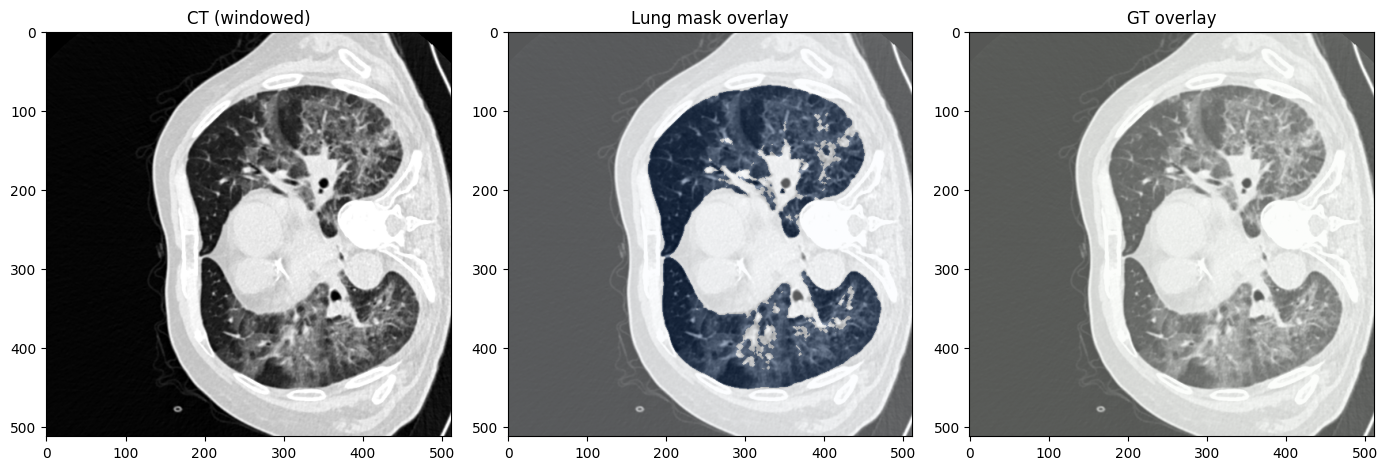

In [12]:
# Visualize middle axial slice with overlays for lung mask and GT
mid = ct.shape[2] // 2
ct_slice = apply_hu_window(ct[:,:,mid], window_level=-600, window_width=1500)
lung_mask = get_lung_mask(ct, body_threshold=-700)
fig, ax = plt.subplots(1,3,figsize=(14,5))
ax[0].imshow(ct_slice, cmap='gray')
ax[0].set_title('CT (windowed)')
ax[1].imshow(ct_slice, cmap='gray')
ax[1].imshow(lung_mask[:,:,mid], alpha=0.35, cmap='Blues')
ax[1].set_title('Lung mask overlay')
ax[2].imshow(ct_slice, cmap='gray')
ax[2].imshow(gt_bin[:,:,mid], alpha=0.35, cmap='Greens')
ax[2].set_title('GT overlay')
plt.tight_layout()
plt.show()

lung percentiles: [-938. -898. -871. -798. -664. -529. -430. -372. -208.]
gt percentiles: [-882. -817. -770. -669. -544. -419. -271. -134.   51.]


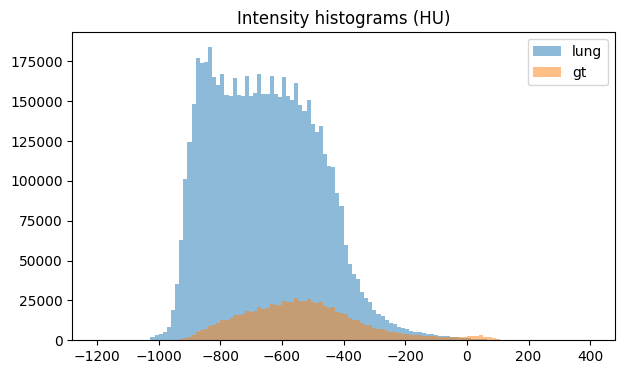

In [13]:
# Intensity histograms and percentiles within lung vs GT
lung_vals = ct[lung_mask.astype(bool)]
gt_vals = ct[gt_bin.astype(bool)]
print('lung percentiles:', np.percentile(lung_vals, [1,5,10,25,50,75,90,95,99]))
print('gt percentiles:', np.percentile(gt_vals, [1,5,10,25,50,75,90,95,99]))
plt.figure(figsize=(7,4))
plt.hist(lung_vals.flatten(), bins=120, range=(-1200,400), alpha=0.5, label='lung')
plt.hist(gt_vals.flatten(), bins=120, range=(-1200,400), alpha=0.5, label='gt')
plt.legend()
plt.title('Intensity histograms (HU)')
plt.show()

In [14]:
# Quick threshold sweep (coarse grid) to find promising HU band
lo_range = list(range(-900, -399, 50))
hi_range = list(range(-350, -149, 50))
results = []
for lo in lo_range:
    for hi in hi_range:
        if lo >= hi:
            continue
        pred = detect_ggo(ct, lung_mask, lower_hu=lo, upper_hu=hi, adaptive=False)
        d = compute_dice(pred, gt_bin)
        j = compute_jaccard(pred, gt_bin)
        results.append((float(d), float(j), lo, hi))
# sort by Dice
results_sorted = sorted(results, key=lambda x: x[0], reverse=True)
print('Top 5 threshold candidates (Dice, Jaccard, lo, hi):')
for r in results_sorted[:5]:
    print(r)

Top 5 threshold candidates (Dice, Jaccard, lo, hi):
(0.27950865883785775, 0.16245862571389505, -650, -150)
(0.27929910874856817, 0.16231705938470192, -650, -200)
(0.2780308692237689, 0.16146100662004192, -650, -250)
(0.275873170115106, 0.16000746890153308, -700, -200)
(0.27586587019388, 0.16000255747208092, -700, -150)


Best band: -650 -150 Dice: 0.27950865883785775


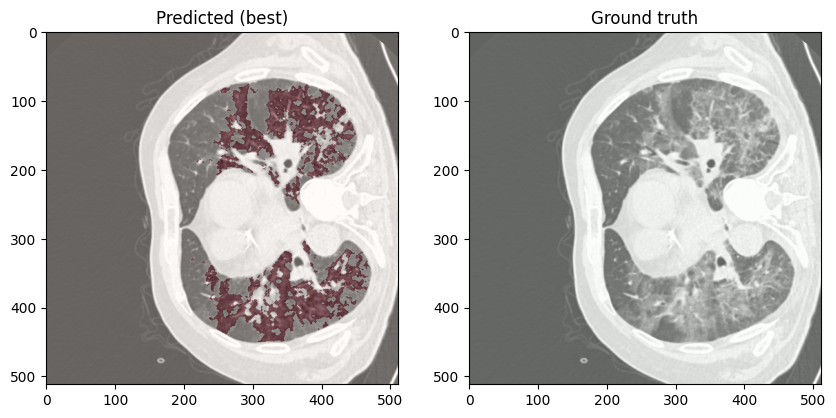

In [15]:
# Visualize best candidate vs GT on middle slice
if len(results_sorted) > 0:
    best = results_sorted[0]
    lo_best, hi_best = best[2], best[3]
    pred_best = detect_ggo(ct, lung_mask, lower_hu=lo_best, upper_hu=hi_best, adaptive=False)
    print('Best band:', lo_best, hi_best, 'Dice:', best[0])
    fig, ax = plt.subplots(1,2,figsize=(10,5))
    ax[0].imshow(apply_hu_window(ct[:,:,mid]), cmap='gray')
    ax[0].imshow(pred_best[:,:,mid], alpha=0.4, cmap='Reds')
    ax[0].set_title('Predicted (best)')
    ax[1].imshow(apply_hu_window(ct[:,:,mid]), cmap='gray')
    ax[1].imshow(gt_bin[:,:,mid], alpha=0.4, cmap='Greens')
    ax[1].set_title('Ground truth')
    plt.show()
else:
    print('No results from sweep (unexpected).')

In [16]:
# Save example outputs
out_dir = os.path.join('..','outputs','eda_examples')
os.makedirs(out_dir, exist_ok=True)
if len(results_sorted) > 0:
    # save overlay of prediction best and GT as PNGs (middle slice)
    import imageio
    rgb_pred = np.stack([apply_hu_window(ct[:,:,mid])]*3, axis=-1)
    # overlay red where pred mask
    rgb_pred[pred_best[:,:,mid].astype(bool), 0] = 1.0
    rgb_gt = np.stack([apply_hu_window(ct[:,:,mid])]*3, axis=-1)
    rgb_gt[gt_bin[:,:,mid].astype(bool), 1] = 1.0
    imageio.imsave(os.path.join(out_dir, 'overlay_pred_best.png'), (rgb_pred * 255).astype(np.uint8))
    imageio.imsave(os.path.join(out_dir, 'overlay_gt.png'), (rgb_gt * 255).astype(np.uint8))
    np.savez_compressed(os.path.join(out_dir, 'threshold_sweep.npz'), results=results_sorted)
    print('Saved overlays to', out_dir)
else:
    print('No sweep results to save.')

Saved overlays to ..\outputs\eda_examples


In [2]:
# Multi-case validation comparing preprocessing options
import os
import numpy as np
import pandas as pd
import scipy.ndimage as ndimage

try:
    from pipeline import load_nifti_with_meta, preprocess_ct, normalize_binary_mask, get_lung_mask, detect_ggo, compute_dice, compute_jaccard
except Exception as e:
    print('Import error from pipeline:', e)
    import sys
    sys.path.append(os.getcwd())
    from pipeline import load_nifti_with_meta, preprocess_ct, normalize_binary_mask, get_lung_mask, detect_ggo, compute_dice, compute_jaccard

pairs = []
data_root = os.path.join('..','data','data_volumes')
seg_root = os.path.join('..','data','segmentations')
# discover a few CT/GT pairs automatically
for root, dirs, files in os.walk(data_root):
    for f in files:
        if not (f.endswith('.nii') or f.endswith('.nii.gz')):
            continue
        ct_p = os.path.join(root, f)
        seg_candidate = os.path.join(seg_root, f)
        if os.path.exists(seg_candidate):
            pairs.append((ct_p, seg_candidate))
        else:
            bn = os.path.splitext(f)[0]
            for sf in os.listdir(seg_root):
                if bn in sf:
                    pairs.append((ct_p, os.path.join(seg_root, sf)))
                    break
    if len(pairs) >= 6:
        break
print('Found pairs:', len(pairs))
rows = []
for ct_p, gt_p in pairs:
    print('Processing', ct_p)
    ct_data, ct_aff, ct_header = load_nifti_with_meta(ct_p)
    gt_data, _, _ = load_nifti_with_meta(gt_p)
    gt_bin_local = normalize_binary_mask(gt_data)

    proc_a, win_a = preprocess_ct(ct_data, current_spacing=None, target_spacing=None)
    lung_a = get_lung_mask(proc_a)
    pred_a = detect_ggo(proc_a, lung_a, lower_hu=-650, upper_hu=-250, adaptive=False)
    d_a = compute_dice(pred_a, gt_bin_local)
    j_a = compute_jaccard(pred_a, gt_bin_local)

    d_b = None
    j_b = None
    try:
        spacing = tuple(ct_header.get_zooms()[:3])
        proc_b, win_b = preprocess_ct(ct_data, current_spacing=spacing, target_spacing=(1.0,1.0,1.0))
        lung_b = get_lung_mask(proc_b)
        pred_b = detect_ggo(proc_b, lung_b, lower_hu=-650, upper_hu=-250, adaptive=False)
        zoom_factors = np.array(proc_b.shape, dtype=float) / np.array(gt_bin_local.shape, dtype=float)
        gt_resampled = ndimage.zoom(gt_bin_local.astype(np.uint8), zoom_factors, order=0).astype(bool)
        if gt_resampled.shape != pred_b.shape:
            raise ValueError(f'resampled GT shape {gt_resampled.shape} does not match prediction shape {pred_b.shape}')
        d_b = compute_dice(pred_b, gt_resampled)
        j_b = compute_jaccard(pred_b, gt_resampled)
    except Exception as e:
        print('Resample validation skipped for', ct_p, 'reason:', e)

    rows.append({
        'ct': ct_p, 'gt': gt_p,
        'dice_no_resample': float(d_a), 'jaccard_no_resample': float(j_a),
        'dice_resample_1mm': (float(d_b) if d_b is not None else None),
        'jaccard_resample_1mm': (float(j_b) if j_b is not None else None)
    })

df = pd.DataFrame(rows)
os.makedirs(os.path.join('..','outputs','eda_examples'), exist_ok=True)
out_csv = os.path.join('..','outputs','eda_examples','validation_summary.csv')
df.to_csv(out_csv, index=False)
print('Saved validation summary to', out_csv)
df

Found pairs: 6
Processing ..\data\data_volumes\train_102\train_102_b\train_102_b_1.nii.gz
Processing ..\data\data_volumes\train_102\train_102_c\train_102_c_1.nii.gz
Processing ..\data\data_volumes\train_106\train_106_a\train_106_a_1.nii.gz
Processing ..\data\data_volumes\train_107\train_107_a\train_107_a_1.nii.gz
Processing ..\data\data_volumes\train_107\train_107_b\train_107_b_2.nii.gz
Processing ..\data\data_volumes\train_107\train_107_c\train_107_c_2.nii.gz
Saved validation summary to ..\outputs\eda_examples\validation_summary.csv


,ct,gt,dice_no_resample,jaccard_no_resample,dice_resample_1mm,jaccard_resample_1mm
0,..\data\data_volumes\train_102\train_102_b\tra...,..\data\segmentations\train_102_b_1.nii.gz,0.109511,0.057927,0.101785,0.053622
1,..\data\data_volumes\train_102\train_102_c\tra...,..\data\segmentations\train_102_c_1.nii.gz,0.142603,0.076776,0.133941,0.071777
2,..\data\data_volumes\train_106\train_106_a\tra...,..\data\segmentations\train_106_a_1.nii.gz,0.049352,0.025300,0.063589,0.032838
3,..\data\data_volumes\train_107\train_107_a\tra...,..\data\segmentations\train_107_a_1.nii.gz,0.000000,0.000000,0.000000,0.000000
4,..\data\data_volumes\train_107\train_107_b\tra...,..\data\segmentations\train_107_b_2.nii.gz,0.112929,0.059844,0.127687,0.068198
5,..\data\data_volumes\train_107\train_107_c\tra...,..\data\segmentations\train_107_c_2.nii.gz,0.163156,0.088824,0.165368,0.090137


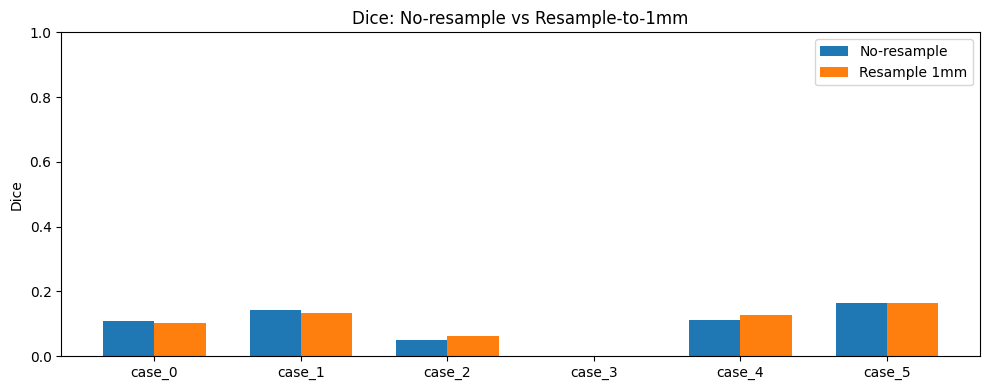

In [3]:
# Plot summary of the validation CSV
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
csv_p = os.path.join('..','outputs','eda_examples','validation_summary.csv')
if os.path.exists(csv_p):
    df = pd.read_csv(csv_p)
    if df.empty:
        print('Validation CSV exists but contains no rows:', csv_p)
    else:
        df_plot = df[['dice_no_resample','dice_resample_1mm']].apply(pd.to_numeric, errors='coerce').dropna(how='all')
        if df_plot.empty:
            print('No numeric Dice values available to plot.')
            display(df)
        else:
            df_plot = df_plot.reset_index(drop=True)
            x = np.arange(len(df_plot))
            width = 0.35
            plt.figure(figsize=(10,4))
            plt.bar(x - width/2, df_plot['dice_no_resample'], width, label='No-resample')
            if 'dice_resample_1mm' in df_plot.columns:
                plt.bar(x + width/2, df_plot['dice_resample_1mm'], width, label='Resample 1mm')
            plt.xticks(x, [f'case_{i}' for i in range(len(df_plot))], rotation=0)
            plt.title('Dice: No-resample vs Resample-to-1mm')
            plt.ylabel('Dice')
            plt.ylim(0, 1)
            plt.legend()
            plt.tight_layout()
            plt.show()
else:
    print('Validation CSV not found at', csv_p)
